In [ ]:
#Algorithm outline and testing

In [1]:
# === PART 1: DETECT & LOCALIZE FLIES PER FRAME ===
""" goal is to record latency of frame substraction, ensure that program can keep track of multiple flies in each frame """

#imports
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from collections import deque

In [5]:
#constants
VIDEO_PATH = "LUCID_TRI032S-M_251700592__20251114112116359_video3.avi" #path to AVI file
DOWNSCALE = 1.0 #<1.0 to downscale frames for speed
THRESH_VAL = 25 # frame subtraction threshold
MIN_AREA = 5 # minimum blob area (pixels)
MAX_AREA = 500 # max blob area (pixels)
MAX_MISSED = 10 # allows tracks to survive 10 frames without a detection
MAX_TRACK_DIST = 50 # max distance for track association (pixels)
HISTORY = 50 # frame to keep for plotting

# ROI Configuration
# define ROI as fractions of frame dimensions
ROI_X_MIN = 0.5
ROI_Y_MIN = 0.0

# static object detection
STATIC_THRESH = 120 #grayscale threshold for dark objects 
BACKGROUND_ALPHA = 0.005 # running background update rate
SLOW_ALPHA = 0.0002
PERSIST_THRESH = 15 # how dark is "fly-like"
PERSIST_FRAMES = 20 #how long it must persist

# Precomputed morphology kernels (create once)
kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
kernel5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

# Precompute a small circle mask for radius 6
CIRCLE_RADIUS = 20
circle_mask = np.zeros((2*CIRCLE_RADIUS+1, 2*CIRCLE_RADIUS+1), dtype=np.uint8)
cv2.circle(circle_mask, (CIRCLE_RADIUS, CIRCLE_RADIUS), CIRCLE_RADIUS, 255, -1)



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [7]:
#tracking class
class Track: 
    def __init__(self, track_id, centroid): 
        self.id = track_id
        self.centroids = deque(maxlen=HISTORY)
        self.centroids.append(centroid)
        #self.last_seen = 0 # frame idx when last seen
        self.missed = 0 # num of consecutive frames w/o detection

    @property
    def last_position(self): 
        return self.centroids[-1] # returns last position stored in centroid

In [51]:
# utility functions
def preprocess_and_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    #gray =cv2.equalizeHist(gray)

    h, w = gray.shape 

    # Define ROI fractions (example: right half)
    x0 = int(ROI_X_MIN * w)
    y0 = int(ROI_Y_MIN * h)
    x1 = w
    y1 = h

    roi = gray[y0:y1, x0:x1]

    # force consistent minimum size
    if roi.shape[0] < 8 or roi.shape[1] < 8:
        raise ValueError(f"ROI too small: {roi.shape} from frame {gray.shape}")
    
    #if DOWNSCALE != 1.0:
     #   gray = cv2.resize(
      #      gray,
       #     None,
        #    fx=DOWNSCALE,
         #   fy=DOWNSCALE,
          #  interpolation=cv2.INTER_AREA,
        #)

    return roi, (x0, y0)

def detect_static_objects_fast(curr_gray, bg_model_fast, bg_model_slow, persist_map):

    # take diff compared to slow background so flies don't disappear
    diff_slow = cv2.absdiff(curr_gray, bg_model_slow)

    # pull out dark persistent objects
    static_mask = diff_slow < PERSIST_THRESH

    # accumulate persistence
    persist_map[static_mask] = np.minimum(persist_map[static_mask] +1, 255)
    persist_map[~static_mask]=0

    # binary persistence threshold
    stable = persist_map > PERSIST_FRAMES

    # cheap morphology thresholding
    stable = cv2.morphologyEx(stable.astype(np.uint8)*255, cv2.MORPH_OPEN, kernel3)

    num_labels, _, stats, centroids = cv2.connectedComponentsWithStats(stable)
    detections = []

    for i in range (1, num_labels): 
        area = stats[i, cv2.CC_STAT_AREA]
        if MIN_AREA <= area <= MAX_AREA: 
            detections.append(tuple(centroids[i].astype(int)))
    return detections
    


def detect_moving_objects_fast(prev_gray, curr_gray):
    diff = cv2.absdiff(curr_gray, prev_gray)
    diff = cv2.GaussianBlur(diff, (5,5), 0)
    _, thresh = cv2.threshold(diff, THRESH_VAL, 255, cv2.THRESH_BINARY)
    # reuse kernel3, do NOT create a new one
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel3)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh)
    detections = []
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if MIN_AREA <= area <= MAX_AREA:
            cx, cy = centroids[i]
            detections.append((int(cx), int(cy)))
    return detections, thresh


def associate_detections_to_tracking_fast(detections, tracks, next_id):
    if not detections: 
        for t in tracks: 
            t.missed +=1 
        return [t for t in tracks if t.missed <= MAX_MISSED], next_id

    used = np.zeros(len(detections), dtype=bool)

    # match existing tracks using greedy algorithm 
    for t in tracks: 
        dists = np.linalg.norm(np.array(detections) - np.array(t.last_position), axis = 1)
        idx = np.argmin(dists)

        if dists[idx] < MAX_TRACK_DIST and not used[idx]: 
            t.centroids.append(detections[idx])
            t.missed = 0
            used[idx] = True
        else: 
            t.missed += 1

    # generate new tracks ONLY for unmatched detections
    for i, d in enumerate (detections): 
        if not used[i]: 
            tracks.append(Track(next_id, d))
            next_id += 1

    # remove old tracks
    tracks = [t for t in tracks if t.missed <=MAX_MISSED]

    return tracks, next_id


def merge_detections(move_dets, static_dets, tracks, move_radius = 15, static_radius = 6):
    merged = list(move_dets)

    track_positions = np.array([t.last_position for t in tracks]) if tracks else np.empty((0,2))

    # static is confirmation, not discovery
    for sd in static_dets:
        if len(track_positions) == 0: 
            continue
        dists = np.linalg.norm(track_positions - np.array(sd), axis =1)

        # static deteections only confirm 
        if np.min(dists) < static_radius: 
            merged.append(sd)

    return merged

def deduplicate_tracks(tracks, radius=5): 
    # prevent same location collapse
    if len(tracks) <=1: 
        return tracks

    keep = []
    for t in tracks: 
        if not any(np.linalg.norm(
            np.array(t.last_position) - np.array(k.last_position)
        ) < radius for k in keep): 
            keep.append(t)
    return keep

    

In [53]:
# MAIN PROCESSING LOOP

def process_video(): 
    print(f"beginning...\n") 
    capture = cv2.VideoCapture(VIDEO_PATH)
    assert capture.isOpened(), "Could not open video file"
    
    ret, frame = capture.read()
    if not ret: 
        raise RuntimeError("Failed to read first frame")
        
    prev_gray, roi_offset = preprocess_and_crop(frame)
    
    #initialize background model for static detection
    bg_model_fast = prev_gray.copy() 
    bg_model_slow = prev_gray.copy() #np.ones_like(prev_gray, dtype=np.uint8) * 255
    persist_map=np.zeros_like(prev_gray, dtype=np.uint8)
    
    # instantiate empty arrays for tracking and latency calculations
    tracks = [] #store tracking in array
    next_track_id = 0 
    #explicit multi-target capacity metrics
    latencies, det_counts, track_counts, frames, thresh_frames = [], [], [], [], []
       
        #frames = []
        #thresh_frames = []
    
    # precompute grids ONCE
    H, W = prev_gray.shape
    yy, xx = np.mgrid[0:H, 0:W]
    CIRCLE_RADIUS_SQ = CIRCLE_RADIUS ** 2
    
    frame_idx = 0
    
    #begin loop, occurs over duration of video
    while True: 
        ret, frame = capture.read()
        if not ret: 
            break
    
        start_frame = time.perf_counter() #records detection speed
    
         # Preprocess & crop
        start = time.perf_counter()
        curr_gray, _ = preprocess_and_crop(frame)
        t_preprocess = time.perf_counter() - start
    
        # Moving detection
        start = time.perf_counter()
        move_dets, thresh = detect_moving_objects_fast(prev_gray, curr_gray)
        t_move = time.perf_counter() - start
    
        # Static detection
        start = time.perf_counter()
        static_dets = detect_static_objects_fast(
            curr_gray, bg_model_fast, bg_model_slow, persist_map
        ) #previously used tracks
        t_static = time.perf_counter() - start
    
        # Merge detections + tracking
        start = time.perf_counter()
        detections = merge_detections(move_dets, static_dets, tracks)
        tracks, next_track_id = associate_detections_to_tracking_fast(
            detections, tracks, next_track_id
        )
        tracks = deduplicate_tracks(tracks) # one track per fly, protect stationary leak
        t_tracking = time.perf_counter() - start
    
        # Background update
        start_bg = time.perf_counter()

        # update slow background -- never mask 
        bg_model_slow = cv2.addWeighted(
                bg_model_slow, 1 - SLOW_ALPHA, 
                curr_gray, SLOW_ALPHA, 0)

        # update fast background (mask flies) 
        if len(tracks) == 0:
            # no flies --> full fast update
            bg_model_fast = cv2.addWeighted(
                bg_model_fast, 1 - BACKGROUND_ALPHA,
                curr_gray, BACKGROUND_ALPHA, 0
            )
            
        else:
            fly_mask = np.zeros_like(curr_gray, dtype=np.uint8)
        
            for t in tracks:
                x, y = t.last_position
        
                x0 = max(0, x - CIRCLE_RADIUS)
                y0 = max(0, y - CIRCLE_RADIUS)
                x1 = min(W, x + CIRCLE_RADIUS + 1)
                y1 = min(H, y + CIRCLE_RADIUS + 1)
        
                cm_x0 = x0 - (x - CIRCLE_RADIUS)
                cm_y0 = y0 - (y - CIRCLE_RADIUS)
                cm_x1 = cm_x0 + (x1 - x0)
                cm_y1 = cm_y0 + (y1 - y0)
        
                fly_mask[y0:y1, x0:x1] |= circle_mask[cm_y0:cm_y1, cm_x0:cm_x1]

            # compute blended background ONCE
            blended_fast = cv2.addWeighted(
                bg_model_fast, 1 - BACKGROUND_ALPHA,
                curr_gray, BACKGROUND_ALPHA, 0
            )
            #bg_model[fly_mask == 0] = cv2.addWeighted(
             #   bg_model[fly_mask == 0], 1 - BACKGROUND_ALPHA,
              #  curr_gray[fly_mask == 0], BACKGROUND_ALPHA, 0
            #)
            #update only non-fly pixels TODO is this fast or slow
            bg_model_fast[fly_mask == 0] = blended_fast[fly_mask == 0]
            
        
        t_bg = (time.perf_counter() - start_bg)
        
        # Visualization
        start = time.perf_counter()
        visual = cv2.cvtColor(curr_gray, cv2.COLOR_GRAY2BGR)
        cv2.rectangle(visual, (0,0), (visual.shape[1]-1, visual.shape[0]-1), (255,255,0), 1)
        for t in tracks:
            for i in range(1, len(t.centroids)):
                # repeat n times
                cv2.line(visual, t.centroids[i-1], t.centroids[i], (0,255,0), 1)
            # do NOT repeat n times (moved outside loop)
            cv2.circle(visual, t.last_position, 3, (0,0,255), -1)
            cv2.putText(visual, f"ID {t.id}", (t.last_position[0]+5, t.last_position[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,0,0), 1)
            if frame_idx % 10 == 0:
                frames.append(visual.copy())
                thresh_frames.append(thresh.copy())
        t_vis = time.perf_counter() - start
    
        # Metrics
        total_frame = (time.perf_counter() - start_frame) * 1000.0
        print(f"Frame {frame_idx}: preprocess={t_preprocess*1000:.1f}ms, "
              f"move={t_move*1000:.1f}ms, static={t_static*1000:.1f}ms, "
              f"tracking={t_tracking*1000:.1f}ms, bg={t_bg*1000:.1f}ms, "
              f"vis={t_vis*1000:.1f}ms, total={total_frame:.1f}ms")

        latencies.append(total_frame)
        det_counts.append(len(detections))
        track_counts.append(len(tracks))

    
        prev_gray = curr_gray
        frame_idx += 1
    

    capture.release()
    print ("Done processing.")
    return latencies, det_counts, track_counts, frames, thresh_frames
        

In [55]:
import cProfile
import pstats

#cProfile.run('process_video()', 'profile_results')
#p = pstats.Stats('profile_results')
#p.strip_dirs().sort_stats('cumtime').print_stats(50)

latencies, det_counts, track_counts, frames, thresh_frames = process_video()

beginning...

Frame 0: preprocess=1.4ms, move=10.1ms, static=18.7ms, tracking=0.0ms, bg=2.3ms, vis=1.8ms, total=34.5ms
Frame 1: preprocess=0.8ms, move=6.8ms, static=20.4ms, tracking=0.1ms, bg=7.4ms, vis=1.7ms, total=37.1ms
Frame 2: preprocess=1.2ms, move=8.4ms, static=17.2ms, tracking=0.7ms, bg=6.6ms, vis=1.5ms, total=35.7ms
Frame 3: preprocess=1.9ms, move=11.5ms, static=18.8ms, tracking=0.3ms, bg=7.0ms, vis=3.5ms, total=43.0ms
Frame 4: preprocess=2.9ms, move=9.4ms, static=23.9ms, tracking=0.3ms, bg=10.7ms, vis=1.4ms, total=48.5ms
Frame 5: preprocess=2.0ms, move=13.2ms, static=20.2ms, tracking=0.5ms, bg=7.0ms, vis=2.1ms, total=44.9ms
Frame 6: preprocess=3.1ms, move=11.6ms, static=23.7ms, tracking=0.3ms, bg=7.4ms, vis=3.2ms, total=49.4ms
Frame 7: preprocess=4.3ms, move=12.2ms, static=26.3ms, tracking=0.3ms, bg=12.2ms, vis=5.7ms, total=60.9ms
Frame 8: preprocess=6.6ms, move=17.2ms, static=69.2ms, tracking=0.3ms, bg=24.9ms, vis=15.2ms, total=133.4ms
Frame 9: preprocess=1.6ms, move=37.4ms,

Average per-frame latency: 138.04 ms
Max per-frame latency: 1704.24 ms
Estimated FPS capability: 7.2 FPS


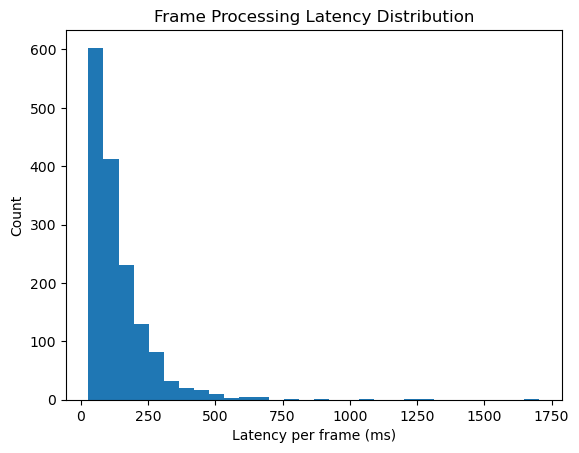

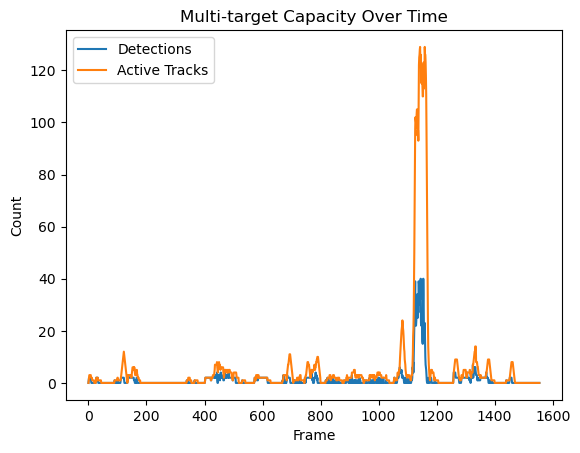

In [57]:
# === RESULTS AND DIAGNOSTICS ===

# latency metrics
#print(f"Processed {frame_idx} frames")
print(f"Average per-frame latency: {np.mean(latencies):.2f} ms")
print(f"Max per-frame latency: {np.max(latencies):.2f} ms")
print(f"Estimated FPS capability: {1000.0 / np.mean(latencies):.1f} FPS")

# plot latency distribution 
plt.figure()
plt.hist(latencies, bins=30)
plt.xlabel("Latency per frame (ms)")
plt.ylabel("Count")
plt.title("Frame Processing Latency Distribution")
plt.show()

#plot detection metrics to quantitatively show scaling behavior
plt.figure()
plt.plot(det_counts, label="Detections")
plt.plot(track_counts, label="Active Tracks")
plt.legend()
plt.title("Multi-target Capacity Over Time")
plt.xlabel("Frame")
plt.ylabel("Count")
plt.show()

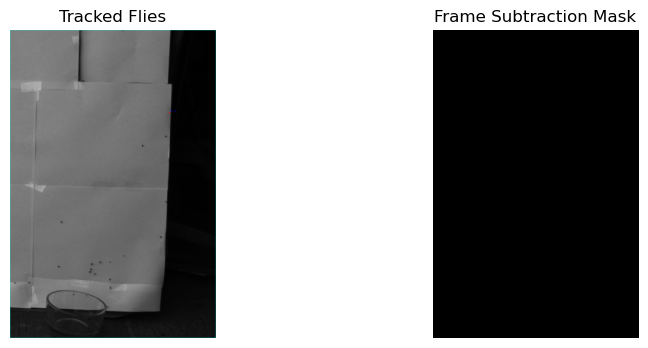

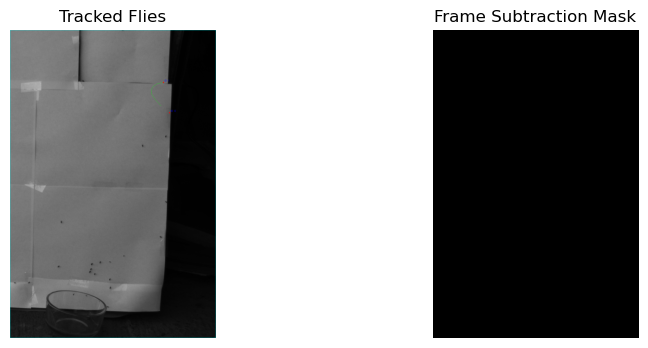

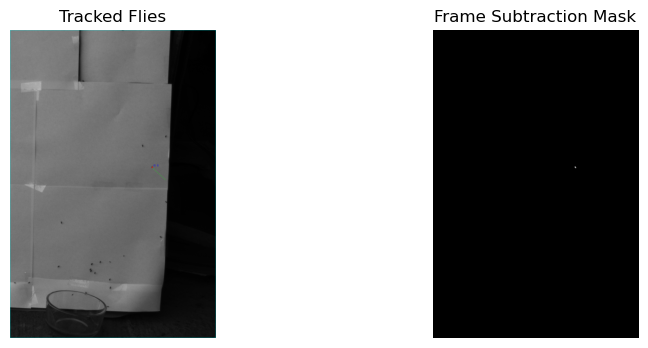

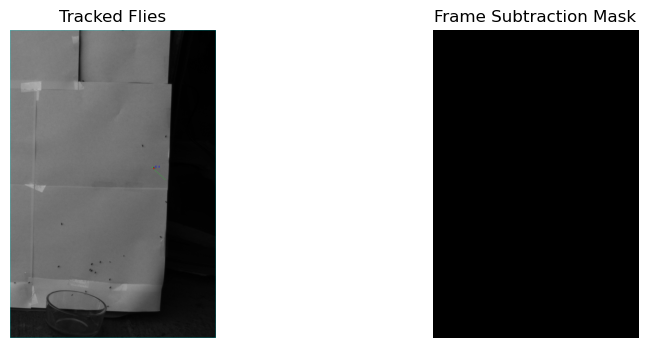

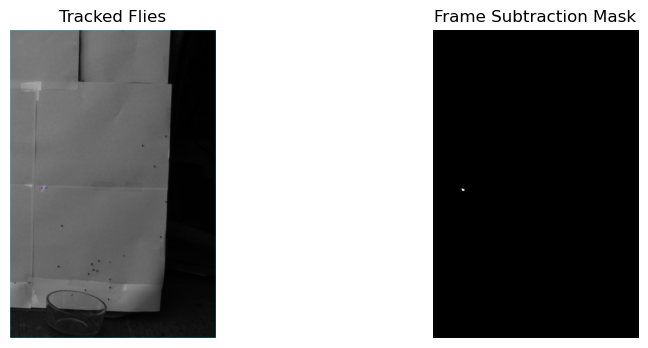

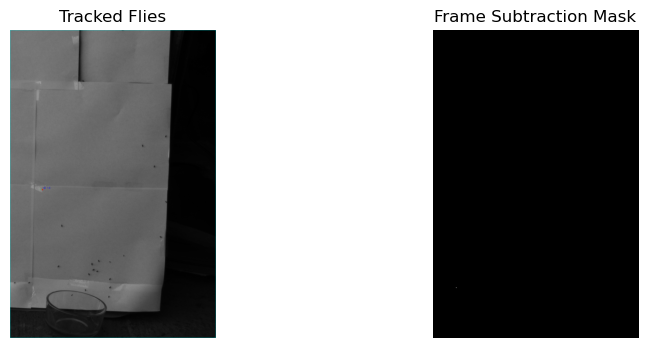

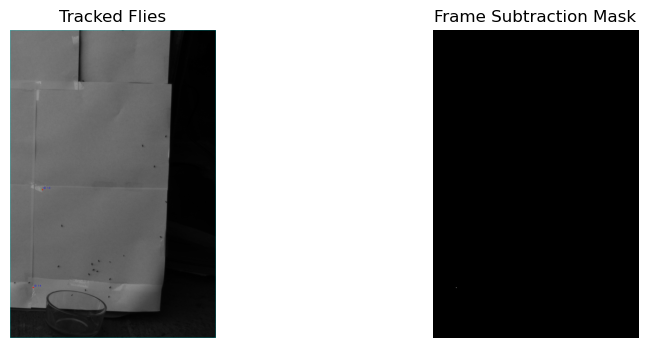

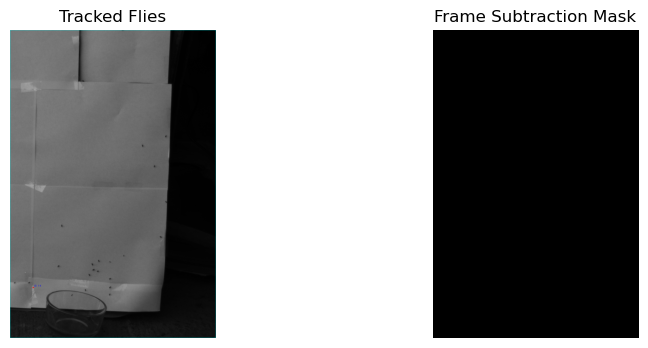

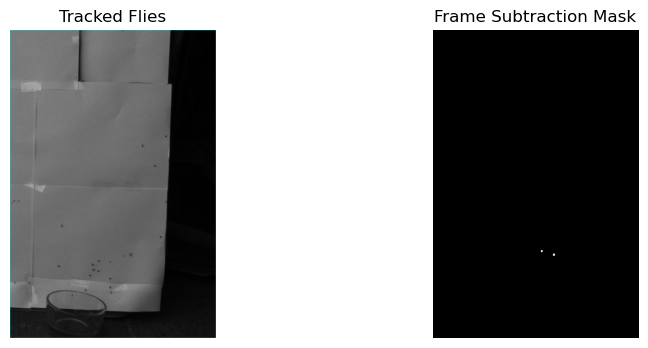

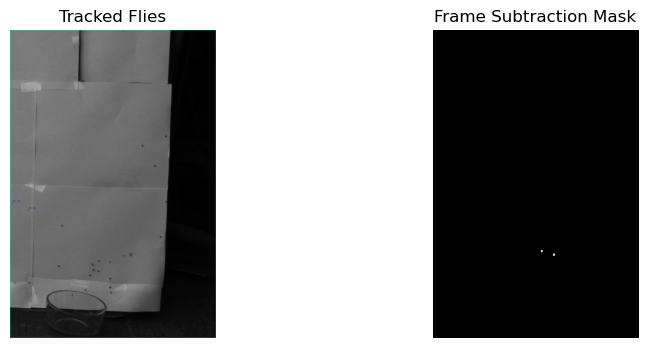

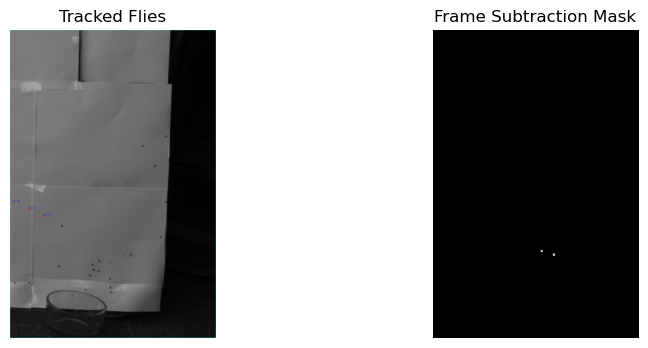

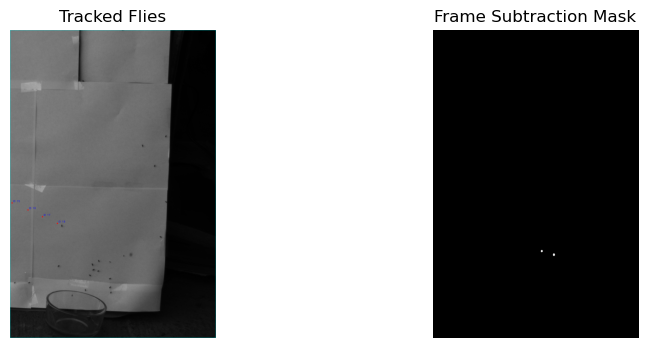

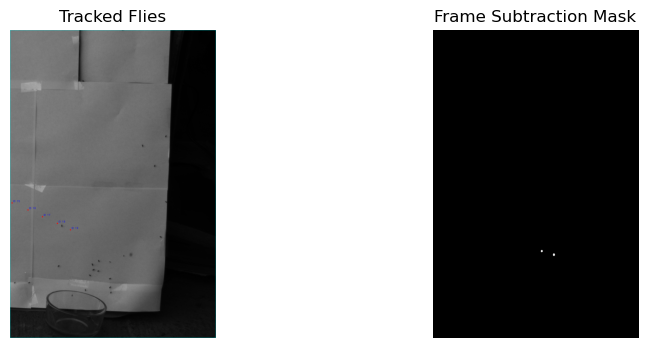

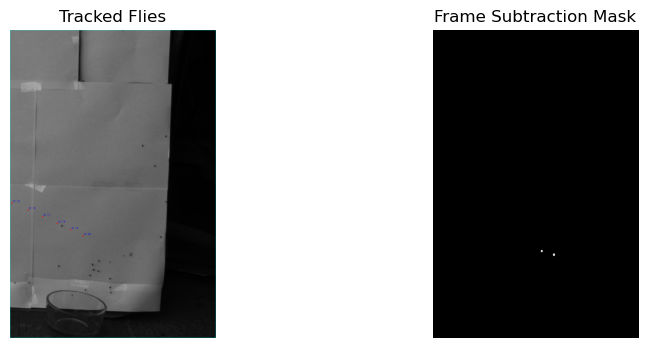

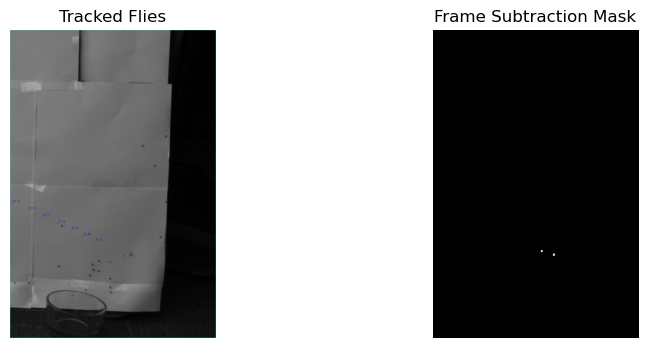

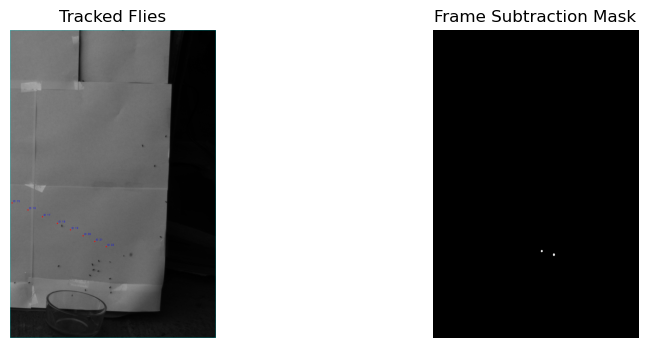

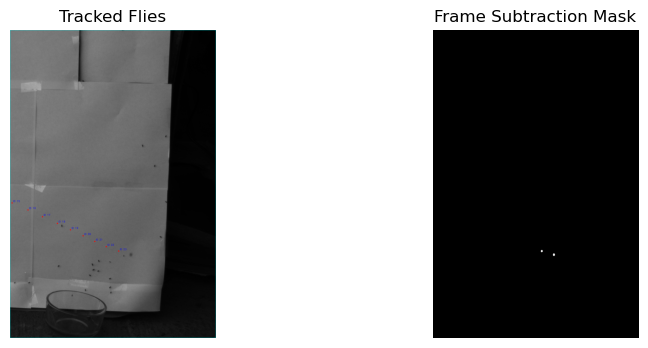

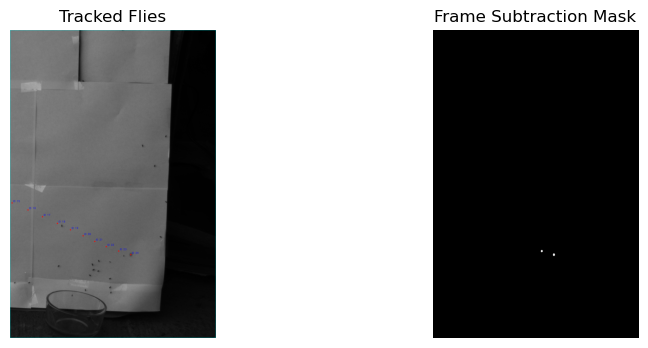

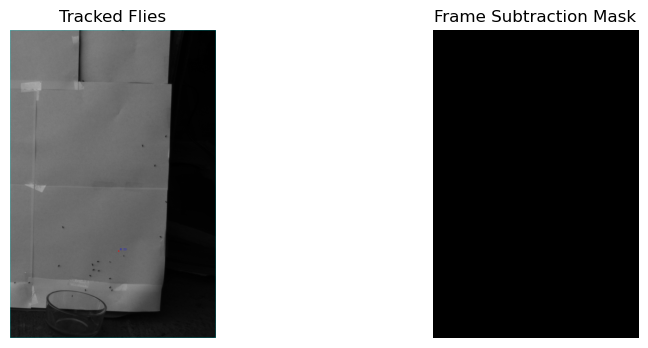

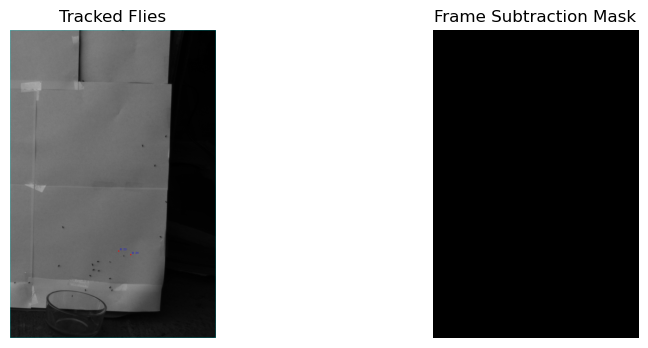

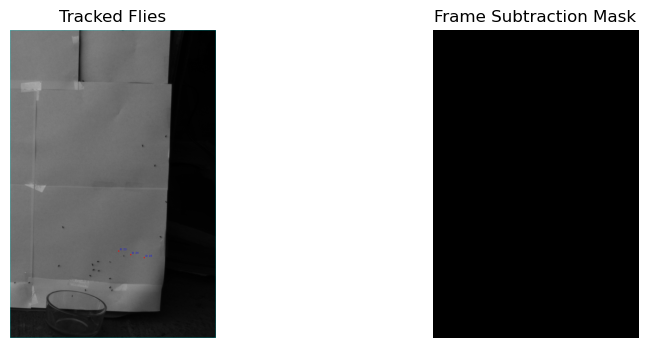

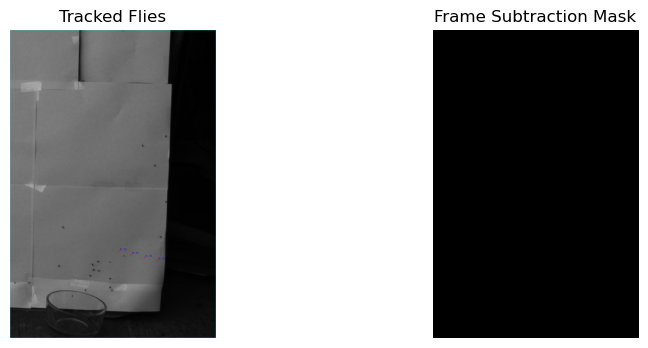

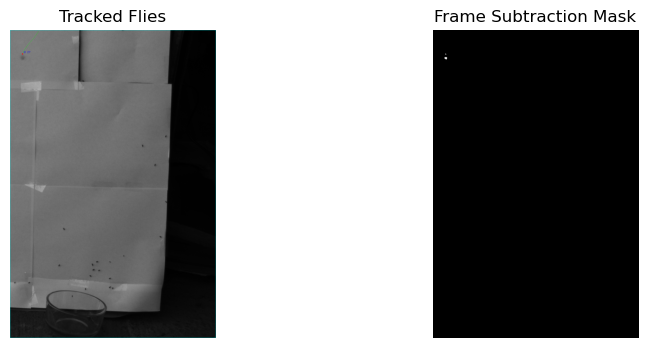

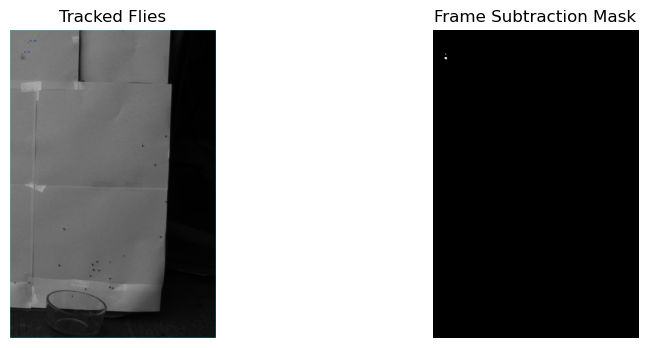

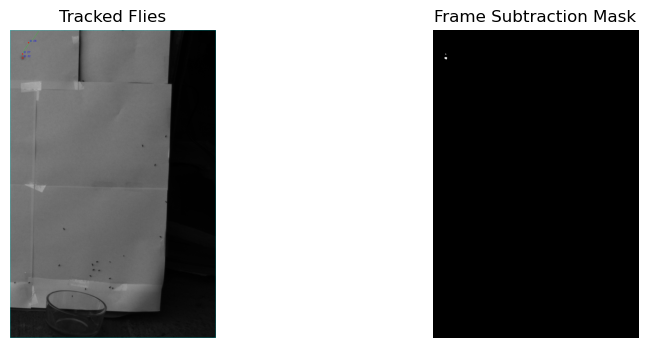

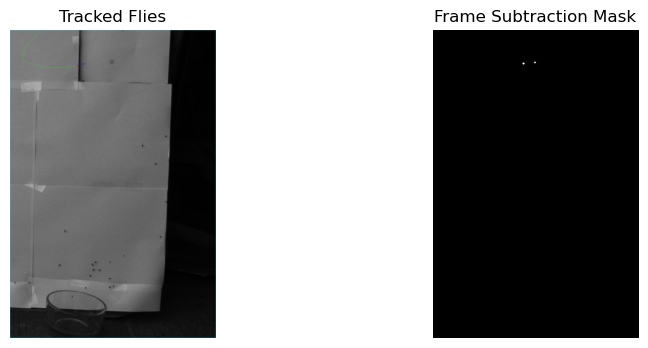

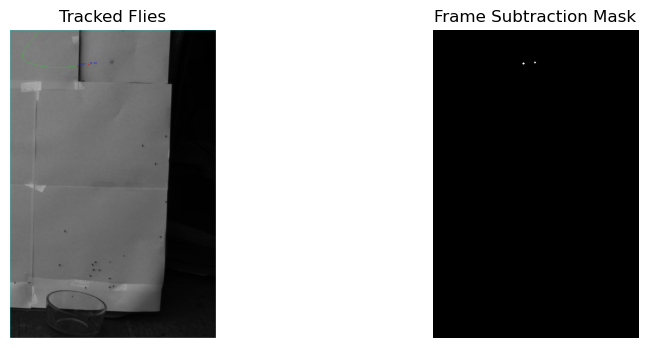

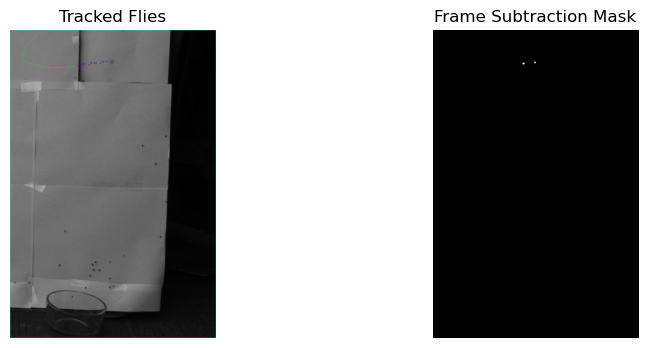

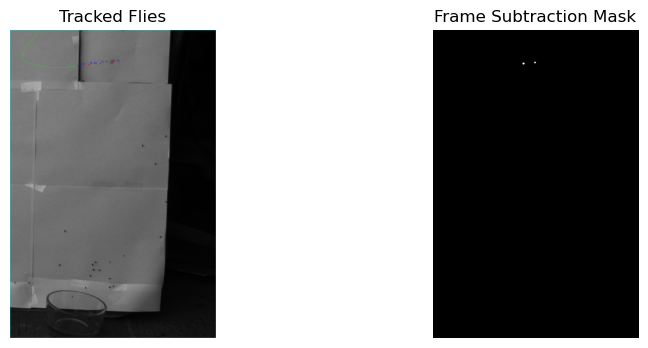

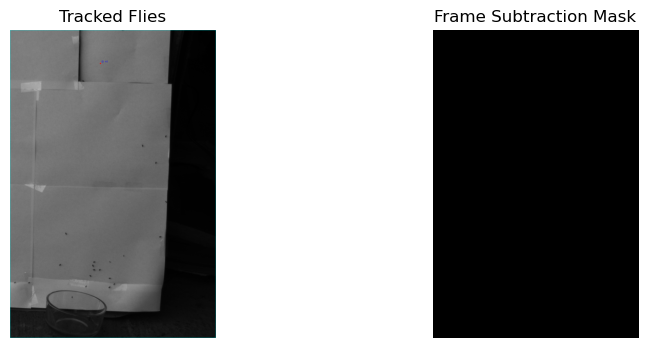

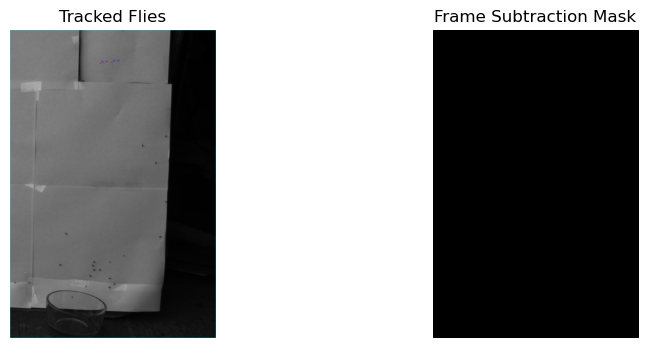

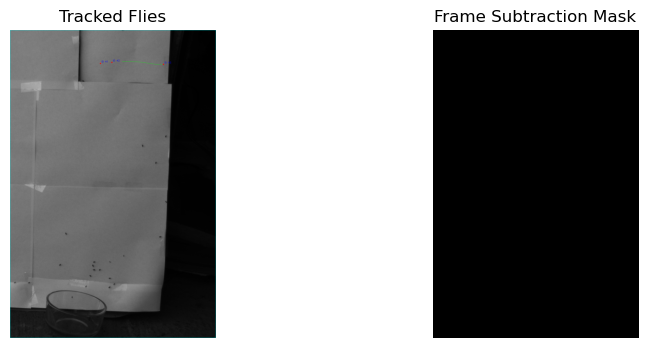

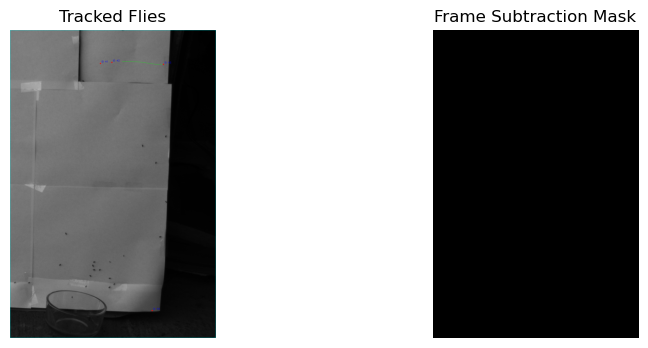

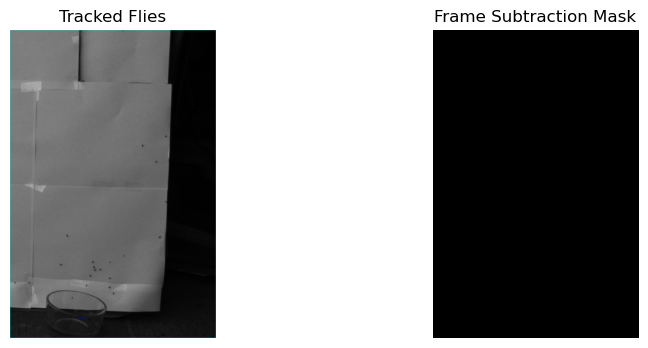

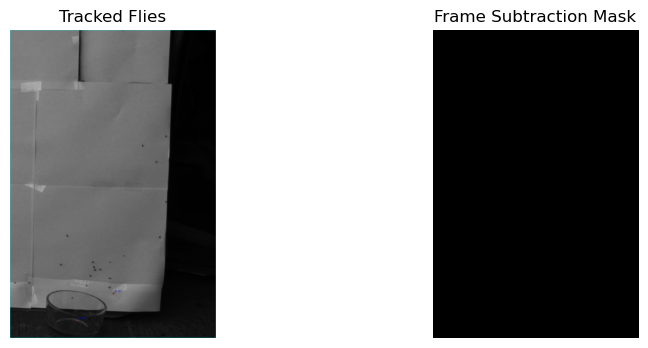

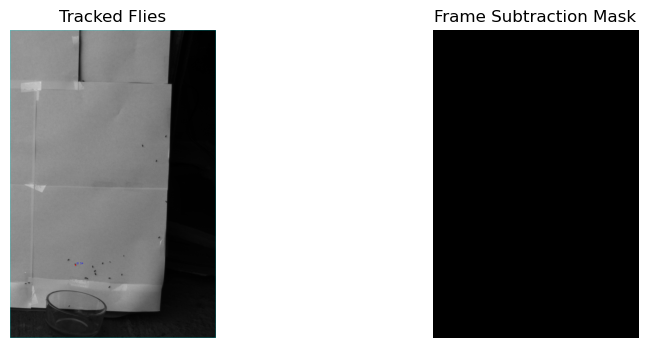

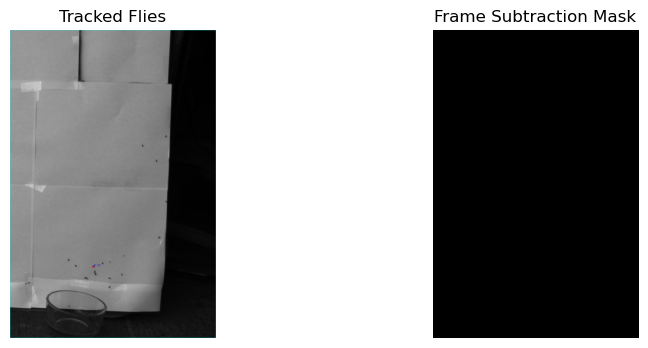

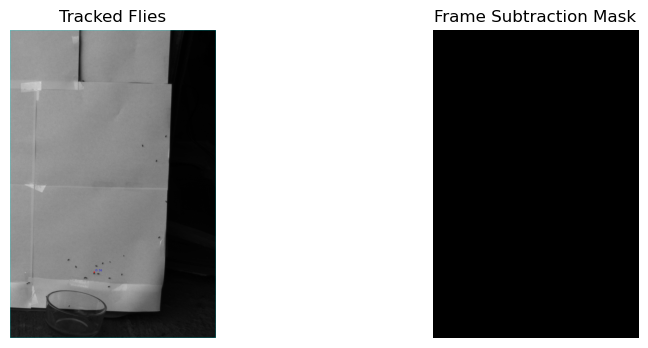

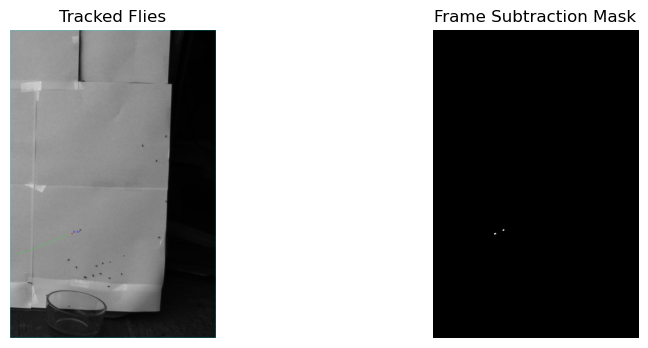

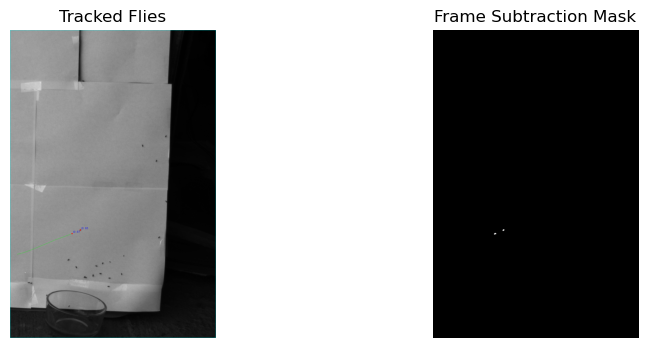

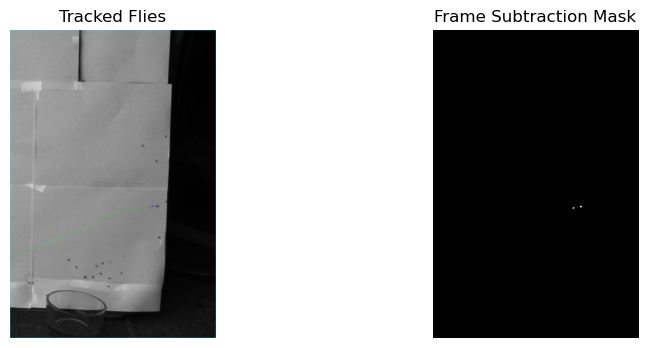

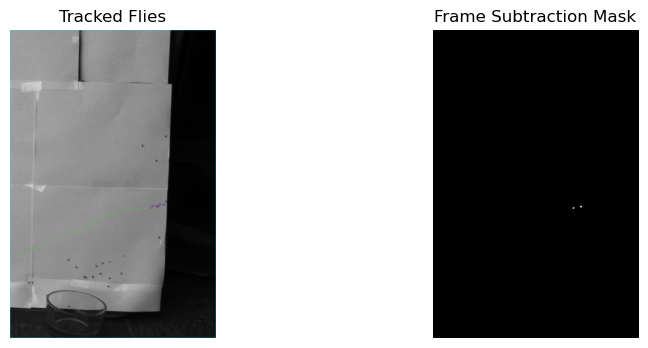

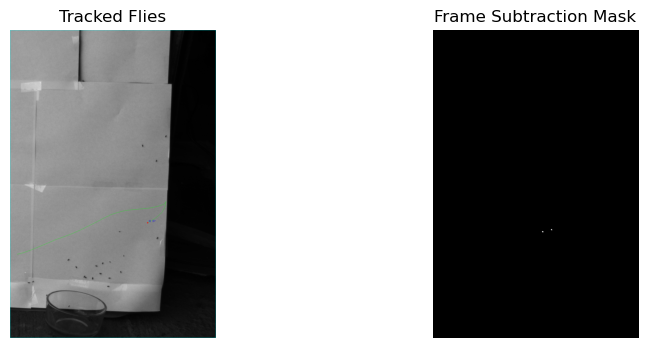

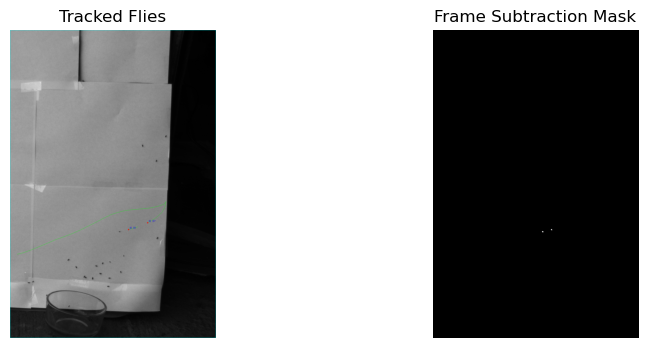

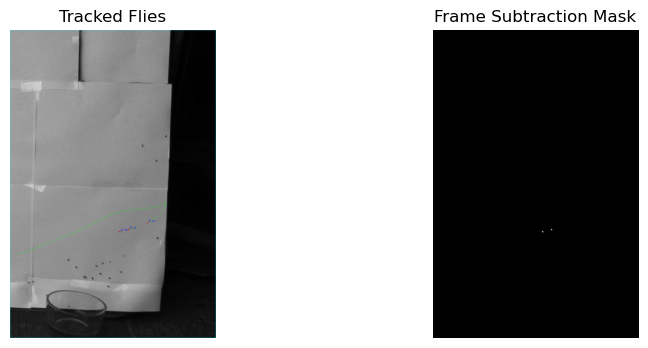

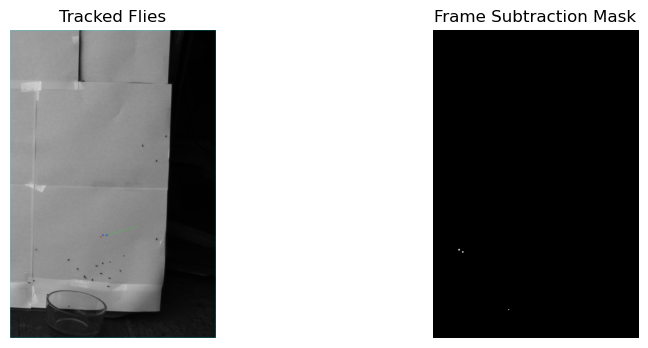

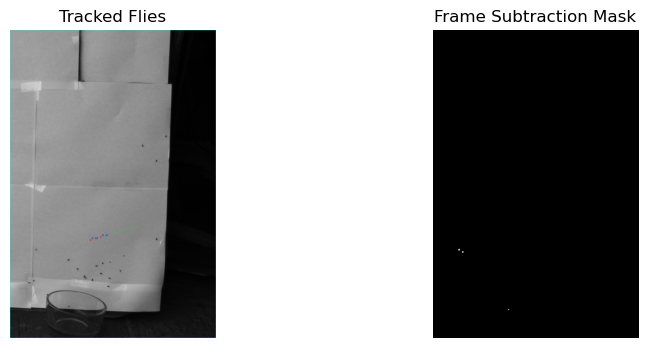

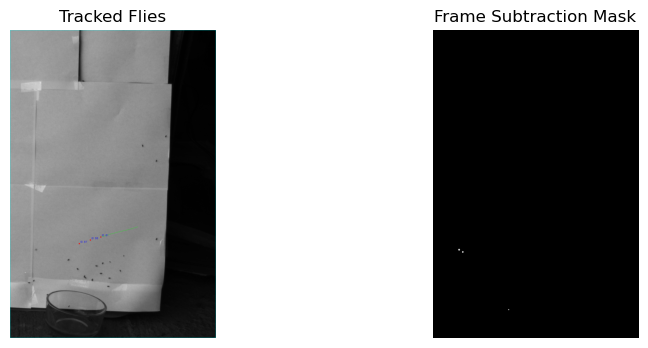

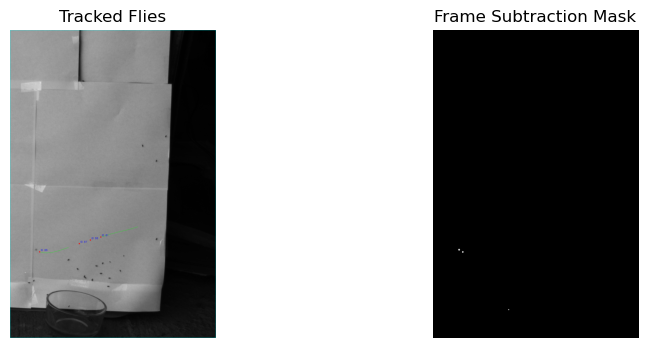

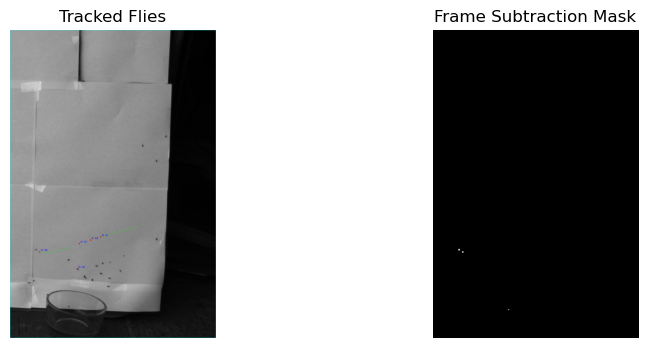

In [59]:
# example frames
num_show = min(50, len(frames))
for i in range(num_show):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(frames[i][..., ::-1])
    plt.title("Tracked Flies")
    plt.axis("off")
    
    
    plt.subplot(1,2,2)
    plt.imshow(thresh_frames[i], cmap='gray')
    plt.title("Frame Subtraction Mask")
    plt.axis("off")
    plt.show()